### By Thanh Pham tp25449

# Review of Part 2

In Part 2, the stiff overdamped spring system was modeled by the scalar ODE

$$
x'=-5000x+0.002\sin(t).
$$

The stiffness comes from the fast decay term $-5000x$, which creates the fast time scale

$$
t_{\text{fast}}=\frac{1}{5000}=0.0002.
$$

This is much smaller than the time scale of the forcing term $\sin(t)$, which changes on a time scale of about 1 second. Because of this time-scale separation, Forward Euler requires an extremely small step size for stability, while Backward Euler remains stable for much larger step sizes.

In Part 3, the Backward Euler solver is improved by adding Newton-Raphson damping and adaptive step size control.

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# Stiff overdamped spring-mass system
#
# dx/dt = -5000x + 0.002sin(t)

lam = 5000
forcing_coeff = 0.002

x0 = 1.0
t_start = 0.0
t_end = 2.0


def f(t, x):
    return -lam*x + forcing_coeff*np.sin(t)


def exact_solution(t):
    # Solves x' + 5000x = 0.002sin(t)
    a = 10 / 25000001
    b = -0.002 / 25000001
    C = x0 - b

    return C*np.exp(-5000*t) + a*np.sin(t) + b*np.cos(t)

t_exact = np.linspace(t_start, t_end, 3000)
x_exact = exact_solution(t_exact)

In [2]:
#For Reference:
# Newton-Raphson solver for Backward Euler

def newton_solver(x_n, t_next, h, tol=1e-6, max_iter=20):
    # Forward Euler step as initial guess
    x_guess = x_n + h*f(t_next, x_n) #y_n also works 

    for iteration in range(1, max_iter + 1):

        # Residual:
        # R(x_next) = x_next - x_n - h*f(t_next, x_next)
        R = x_guess - x_n - h*f(t_next, x_guess)

        # For f(t,x) = -5000x + 0.002sin(t),
        # taking partial derivative w.r.t to x: dR/dx = 1 - h*(-5000) = 1 + 5000h
        dRdx = 1 + lam*h

        x_new = x_guess - R/dRdx

        if abs(x_new - x_guess) < tol:
            return x_new, iteration, True

        x_guess = x_new

    print("Warning: Newton-Raphson did not converge.")
    return x_guess, max_iter, False


# Backward Euler using Newton-Raphson


def euler_backward(h):
    #initiate empty arrays for recording solution
    t_values = np.arange(t_start, t_end + h, h)
    x_values = np.zeros(len(t_values))
    iteration_counts = np.zeros(len(t_values))

    x_values[0] = x0

    for i in range(1, len(t_values)):
        t_next = t_values[i]
        x_n = x_values[i - 1]

        x_next, iterations, isConverge = newton_solver(x_n, t_next, h)

        x_values[i] = x_next
        iteration_counts[i] = iterations

    return t_values, x_values, iteration_counts



# Newton-Raphson Damping Implementation

For Backward Euler,

$$
x_{n+1}=x_n+h f(t_{n+1},x_{n+1}).
$$

Since \(x_{n+1}\) appears on both sides, we solve the residual equation

$$
R(x_{n+1})=x_{n+1}-x_n-hf(t_{n+1},x_{n+1})=0.
$$

For this problem,

$$
R(x)=x-x_n-h(-5000x+0.002\sin(t_{n+1}))
$$

and 

$$
R'(x)= 1 + 5000h.
$$



Damped Newton-Raphson modifies the usual Newton update by adding a damping factor $\alpha$:

$$
x^{(j+1)}
=
x^{(j)}
-
\alpha \frac{R(x^{(j)})}{R'(x^{(j)})}.
$$

The algorithm starts with $\alpha=1$. If the residual does not decrease, $\alpha$ is cut in half until the residual decreases.

In [3]:
def damped_newton_raphson(x_n, t_next, h, tol=1e-8, max_iter=20, alpha_min=1e-4):
    """
    Damped Newton-Raphson with line search
    """
    x_guess = x_n
    
    for k in range(max_iter):
        # Residual:
        # R(x_next) = x_next - x_n - h*f(t_next, x_next)
        R = x_guess - x_n - h*f(t_next, x_guess)

        # For f(t,x) = -5000x + 0.002sin(t),
        # taking partial derivative w.r.t to x: dR/dx = 1 - h*(-5000) = 1 + 5000h
        dRdx = 1 + lam*h
        
        if abs(R) < tol:
            return x_guess, k, True
        
        delta = -R / dRdx
        
        # Line search for damping factor
        alpha = 1.0
        R_current = abs(R)
        
        for _ in range(10):  # Max 10 backtracking steps
            x_new = x_guess + alpha * delta
            R_new = abs(x_new - x_n - h*f(t_next, x_new))
            
            if R_new < R_current:  # Sufficient decrease
                break
            
            alpha = alpha / 2.0  #alpha halved
            
            if alpha < alpha_min:
                print(f"Warning: alpha too small at iter {k}")
                return x_guess, k, False
        
        x_guess = x_new
    
    return x_guess, max_iter, False

In [4]:
# One Backward Euler step using Newton-Raphson

def backward_euler_step(x_n, t_next, h):
    # Solve one Backward Euler step:
    #
    # x_next = x_n + h*f(t_next, x_next)
    #
    # Since x_next appears on both sides, we use Newton-Raphson.

    x_next, iterations, isConverge = damped_newton_raphson(x_n, t_next, h)

    return x_next, iterations, isConverge

In [5]:
# Step-doubling error estimate

def step_doubling_error(x_n, t_n, h):
    """
    Estimates local error by comparing:

        1 full step of size h

    against

        2 half steps of size h/2

    Returns:
        x_full = solution from one full step
        x_half_2 = solution from two half steps
        error = difference between the two approximations
        total_iterations = Newton iterations used
        converged = whether all Newton solves converged
    """

    # --------------------------------------------------------
    # One full step: t_n -> t_n + h
    # --------------------------------------------------------

    x_full, iter_full, conv_full = backward_euler_step(x_n, t_n + h, h)

    # First half step: t_n -> t_n + h/2
    x_half_1, iter_half_1, conv_half_1 = backward_euler_step(x_n, t_n + h/2, h/2)

    # Second half step: t_n + h/2 -> t_n + h
    x_half_2, iter_half_2, conv_half_2 = backward_euler_step(x_half_1, t_n + h,  h/2)

    # Error estimate
    # If the full-step and half-step answers are close,
    # then h was probably small enough.

    error = abs(x_half_2 - x_full)

    total_iterations = iter_full + iter_half_1 + iter_half_2

    converged = conv_full and conv_half_1 and conv_half_2

    return x_full, x_half_2, error, total_iterations, converged

In [6]:
def adjust_step_size(h_current, error, tol, safety=0.9, 
                     h_min=1e-8, h_max=0.5):
    """
    Compute a new step size based on the step-doubling error estimate.
    
    Since Backward Euler is first order, the local error behaves like O(h^2),
    so the step size update uses:

        h_new = h_current * sqrt(tol / error)

    """

    # If the error is basically zero, increase the step size moderately.
    if error < 1e-14:
        h_new = 2.0 * h_current

    # Otherwise, use the standard adaptive step-size formula.
    else:
        h_new = h_current * np.sqrt(tol / error)

    # Apply safety factor.
    h_new = safety * h_new

    # Do not allow the step size to change too aggressively.
    # This prevents sudden jumps from, for example, h = 0.001 to h = 0.5.
    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))

    # Enforce global minimum and maximum bounds.
    h_new = max(h_min, min(h_max, h_new))

    return h_new

In [7]:
def adaptive_backward_euler(x0, t0, t_final, h0=0.1, tol=1e-5,
                            h_min=1e-8, h_max=0.5, safety=0.9):
    """
    This function uses step_doubling_error() to compare:

        1 full step of size h

    against

        2 half steps of size h/2

    If the estimated error is below the tolerance, the step is accepted.
    If the estimated error is above the tolerance, the step is rejected.
    """

    # Store accepted time and solution values
    t_values = [t0]
    x_values = [x0]

    # Store diagnostic information
    h_values = []
    error_values = []
    iteration_values = []

    # Count rejected steps
    rejected_steps = 0

    # Initial step size
    h = h0

    # Main adaptive time-stepping loop
    while t_values[-1] < t_final:

        # Current accepted time and solution
        t_n = t_values[-1]
        x_n = x_values[-1]

        # Make sure the final step lands exactly on t_final
        if t_n + h > t_final:
            h = t_final - t_n

        # ----------------------------------------------------
        # Estimate error using step-doubling
        # ----------------------------------------------------
        #
        # This returns:
        # x_full          = one full step result
        # x_half          = two half-step result
        # error           = |x_half - x_full|
        # total_iterations = total Newton iterations used
        # converged       = whether all Newton solves converged

        x_full, x_half, error, total_iterations, converged = step_doubling_error(x_n, t_n, h)


        # If Newton-Raphson failed, reject the step
        # We do not move forward in time.
        # We shrink h and try again from the same t_n.

        if not converged:
            rejected_steps += 1
            h = max(h_min, 0.5*h)
            continue

        # Compute suggested new step size

        h_new = adjust_step_size(h_current=h, error=error, tol=tol, safety=safety, h_min=h_min, h_max=h_max)


        # Accept or reject the step based on error
        if error < tol:

            # ACCEPT STEP
            #
            # Store x_half instead of x_full because the two-half-step
            # approximation is usually more accurate.

            t_values.append(t_n + h)
            x_values.append(x_half)

            h_values.append(h)
            error_values.append(error)
            iteration_values.append(total_iterations)

            # Use adjusted step size for next step
            h = h_new

        else:

            # REJECT STEP
            #
            # Do not append anything.
            # Try again from the same t_n with smaller h.

            rejected_steps += 1
            h = h_new

            if h <= h_min:
                print("Warning: step size reached h_min.")
                break

    return (
        np.array(t_values),
        np.array(x_values),
        np.array(h_values),
        np.array(error_values),
        np.array(iteration_values),
        rejected_steps )

# Performance Analysis

The fixed-step Backward Euler method and adaptive Backward Euler method were compared in two ways. First, they were compared using a similar target accuracy. Second, they were compared using a similar step budget. This helps show the tradeoff between computational cost and accuracy.

The fixed-step method uses the same step size throughout the entire simulation. This is simple, but inefficient for stiff systems because the step size must be small enough to capture the fast transient near \(t=0\), even though the solution changes much more slowly afterward.

The adaptive method changes the step size based on a local error estimate from step-doubling. One full Backward Euler step of size \(h\) is compared with two half steps of size \(h/2\). If the two results are close, the step is accepted. If the error is too large, the step is rejected and repeated with a smaller step size.

For this stiff problem, the adaptive method is useful because the solution has a rapid initial transient followed by slower long-term behavior. Therefore, the solver should use smaller steps near the fast decay and larger steps later.

In [8]:
t_adapt, x_adapt, h_values, error_values, iteration_values, rejected_steps = adaptive_backward_euler(
    x0=x0,
    t0=t_start,
    t_final=t_end,
    h0=0.1,
    tol=1e-5,
    h_min=1e-8,
    h_max=0.5,
    safety=0.9
)

print("Adaptive Backward Euler Results")
print("--------------------------------")
print(f"Accepted steps: {len(h_values)}")
print(f"Rejected steps: {rejected_steps}")
print(f"Average step size: {np.mean(h_values)}")
print(f"Minimum step size: {np.min(h_values)}")
print(f"Maximum step size: {np.max(h_values)}")
print(f"Average Newton iterations per accepted step: {np.mean(iteration_values)}")

Adaptive Backward Euler Results
--------------------------------
Accepted steps: 360
Rejected steps: 8
Average step size: 0.005555555555555555
Minimum step size: 1.1449461326298743e-06
Maximum step size: 0.5
Average Newton iterations per accepted step: 2.9972222222222222


In [9]:
# Test undamped vs damped Newton-Raphson

h_large = 5.0  # Very large step size

x_n = x0
t_n = t_start
t_next = t_n + h_large

print("Testing undamped Newton-Raphson with h = 5.0:")

try:
    x_undamped, iters_undamped, success_undamped = newton_solver(
        x_n,
        t_next,
        h_large
    )

    print(f"Converged: {success_undamped}")
    print(f"Iterations: {iters_undamped}")
    print(f"x_next: {x_undamped}")

except:
    print("Failed to converge!")


print("\nTesting damped Newton-Raphson with h = 5.0:")

try:
    x_damped, iters_damped, success_damped = damped_newton_raphson(
        x_n,
        t_next,
        h_large
    )

    print(f"Converged: {success_damped}")
    print(f"Iterations: {iters_damped}")
    print(f"x_next: {x_damped}")

except:
    print("Failed to converge!")

Testing undamped Newton-Raphson with h = 5.0:
Converged: True
Iterations: 2
x_next: 3.961484569630689e-05

Testing damped Newton-Raphson with h = 5.0:
Converged: True
Iterations: 1
x_next: 3.961484569636742e-05


For this problem, undamped Newton-Raphson still converges even with a large step size because the Backward Euler residual is linear in x. Therefore, damping is not strictly necessary for this specific ODE. However, damping is still included because it improves robustness for nonlinear stiff problems, where a full Newton step can overshoot and increase the residual.

In [10]:
# Performance comparison: fixed Backward Euler vs adaptive BE

# Fixed method chosen for comparison
fixed_h = 0.001

t_fixed, x_fixed, fixed_iterations = euler_backward(fixed_h)

# Run adaptive method
t_adapt, x_adapt, h_values, error_values, iteration_values, rejected_steps = adaptive_backward_euler(
    x0=x0,
    t0=t_start,
    t_final=t_end,
    h0=0.1,
    tol=1e-5,
    h_min=1e-8,
    h_max=0.5,
    safety=0.9
)

# Exact/reference solution errors
fixed_error = np.max(np.abs(x_fixed - exact_solution(t_fixed)))
adaptive_error = np.max(np.abs(x_adapt - exact_solution(t_adapt)))

# Step counts
fixed_steps = len(t_fixed) - 1
adaptive_steps = len(t_adapt) - 1

# Newton iteration counts
fixed_total_iterations = np.sum(fixed_iterations[1:])
adaptive_total_iterations = np.sum(iteration_values)

# Function evaluation estimate
#
# For fixed Backward Euler:
# each Newton iteration evaluates the residual once.
#
# For adaptive Backward Euler:
# each accepted adaptive step uses 3 Backward Euler solves:
# 1 full step and 2 half steps.
#
# Since iteration_values already stores total Newton iterations from those solves,
# we can estimate function evaluations using total Newton iterations.
fixed_function_evals = fixed_total_iterations
adaptive_function_evals = adaptive_total_iterations

print("Fixed vs Adaptive Backward Euler Comparison")
print("--------------------------------------------------------------------------")
print(f"{'Method':<25}{'Steps':<12}{'Newton Iters':<18}{'Func Evals':<15}{'Max Error'}")
print("--------------------------------------------------------------------------")
print(f"{'Fixed BE':<25}{fixed_steps:<12}{int(fixed_total_iterations):<18}{int(fixed_function_evals):<15}{fixed_error:.6e}")
print(f"{'Adaptive BE':<25}{adaptive_steps:<12}{int(adaptive_total_iterations):<18}{int(adaptive_function_evals):<15}{adaptive_error:.6e}")
print("--------------------------------------------------------------------------")
print(f"Rejected adaptive steps: {rejected_steps}")

Fixed vs Adaptive Backward Euler Comparison
--------------------------------------------------------------------------
Method                   Steps       Newton Iters      Func Evals     Max Error
--------------------------------------------------------------------------
Fixed BE                 2000        2009              2009           1.599287e-01
Adaptive BE              360         1079              1079           7.114929e-04
--------------------------------------------------------------------------
Rejected adaptive steps: 8


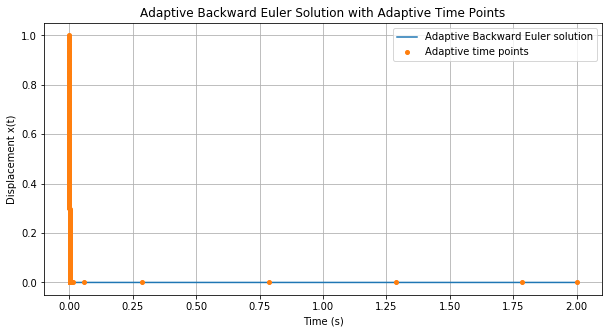

In [11]:
# Plot: adaptive solution with adaptive time points marked

plt.figure(figsize=(10, 5))

# Connect the adaptive solution values with a line
plt.plot(
    t_adapt,
    x_adapt,
    "-",
    label="Adaptive Backward Euler solution"
)

# Mark the actual time points selected by the adaptive solver
plt.plot(
    t_adapt,
    x_adapt,
    "o",
    markersize=4,
    label="Adaptive time points"
)

plt.title("Adaptive Backward Euler Solution with Adaptive Time Points")
plt.xlabel("Time (s)")
plt.ylabel("Displacement x(t)")
plt.legend()
plt.grid(True)

plt.show()

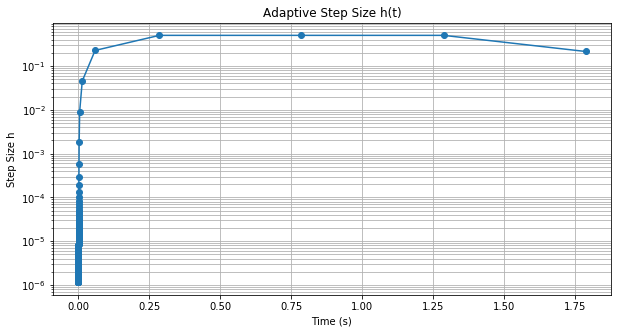

In [12]:
# Plot: adaptive step size history

plt.figure(figsize=(10, 5))

plt.semilogy(t_adapt[:-1], h_values, "o-") #creat plot with log scale

plt.title("Adaptive Step Size h(t)")
plt.xlabel("Time (s)")
plt.ylabel("Step Size h")
plt.grid(True, which="both")

plt.show()

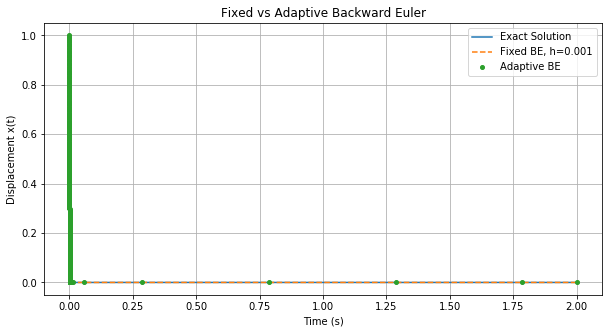

In [13]:
# Plot: fixed vs adaptive Backward Euler

plt.figure(figsize=(10, 5))

plt.plot(t_exact, x_exact, label="Exact Solution")
plt.plot(t_fixed, x_fixed, "--", label=f"Fixed BE, h={fixed_h}")
plt.plot(t_adapt, x_adapt, "o", markersize=4, label="Adaptive BE")

plt.title("Fixed vs Adaptive Backward Euler")
plt.xlabel("Time (s)")
plt.ylabel("Displacement x(t)")
plt.legend()
plt.grid(True)

plt.show()

# Robustness Testing

The adaptive Backward Euler solver was tested under two more difficult conditions. First, the initial step size was chosen to be very large, $h_0=1.0$. This tests whether the adaptive method can reject inaccurate steps and reduce the step size automatically. Second, the tolerance was tightened to $10^{-8}$. This tests whether the method can increase accuracy by taking smaller steps when needed.

In [14]:
# Robustness Test 1: large initial step size
t_large, x_large, h_large_values, err_large_values, iter_large_values, rejected_large = adaptive_backward_euler(
    x0=x0,
    t0=t_start,
    t_final=t_end,
    h0=1.0,
    tol=1e-5,
    h_min=1e-8,
    h_max=1.0,
    safety=0.9
)

large_error = np.max(np.abs(x_large - exact_solution(t_large)))

print("Robustness Test 1: Large Initial Step Size")
print("------------------------------------------")
print(f"Initial step size h0: 1.0")
print(f"Accepted steps: {len(h_large_values)}")
print(f"Rejected steps: {rejected_large}")
print(f"Minimum accepted h: {np.min(h_large_values):.6e}")
print(f"Maximum accepted h: {np.max(h_large_values):.6e}")
print(f"Max error: {large_error:.6e}")

Robustness Test 1: Large Initial Step Size
------------------------------------------
Initial step size h0: 1.0
Accepted steps: 358
Rejected steps: 9
Minimum accepted h: 1.144988e-06
Maximum accepted h: 1.000000e+00
Max error: 7.115061e-04


In [15]:
# Robustness Test 2: tight tolerance

t_tight, x_tight, h_tight_values, err_tight_values, iter_tight_values, rejected_tight = adaptive_backward_euler(
    x0=x0,
    t0=t_start,
    t_final=t_end,
    h0=0.1,
    tol=1e-8,
    h_min=1e-10,
    h_max=0.5,
    safety=0.9
)

tight_error = np.max(np.abs(x_tight - exact_solution(t_tight)))

print("Robustness Test 2: Tight Tolerance")
print("----------------------------------")
print(f"Tolerance: 1e-8")
print(f"Accepted steps: {len(h_tight_values)}")
print(f"Rejected steps: {rejected_tight}")
print(f"Minimum accepted h: {np.min(h_tight_values):.6e}")
print(f"Maximum accepted h: {np.max(h_tight_values):.6e}")
print(f"Max error: {tight_error:.6e}")

Robustness Test 2: Tight Tolerance
----------------------------------
Tolerance: 1e-8
Accepted steps: 11120
Rejected steps: 10
Minimum accepted h: 3.600648e-08
Maximum accepted h: 5.000000e-01
Max error: 2.250000e-05


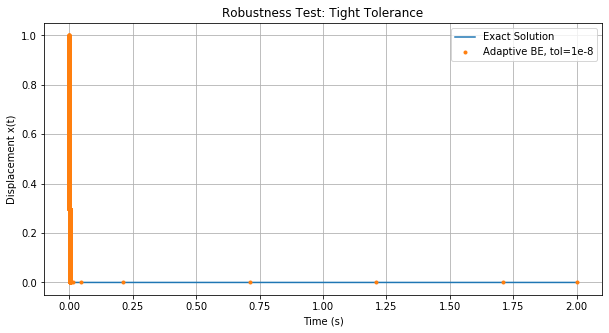

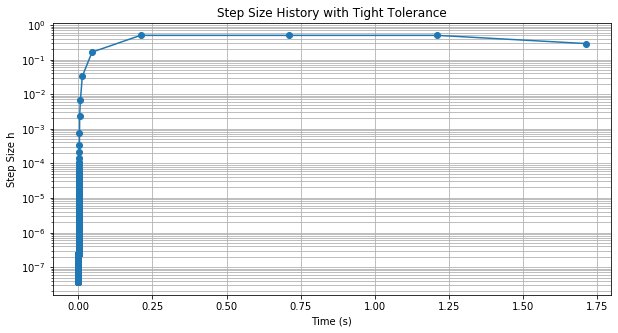

In [16]:
plt.figure(figsize=(10, 5))

plt.plot(t_exact, x_exact, label="Exact Solution")
plt.plot(t_tight, x_tight, "o", markersize=3, label="Adaptive BE, tol=1e-8")

plt.title("Robustness Test: Tight Tolerance")
plt.xlabel("Time (s)")
plt.ylabel("Displacement x(t)")
plt.legend()
plt.grid(True)

plt.show()

plt.figure(figsize=(10, 5))

plt.semilogy(t_tight[:-1], h_tight_values, "o-")

plt.title("Step Size History with Tight Tolerance")
plt.xlabel("Time (s)")
plt.ylabel("Step Size h")
plt.grid(True, which="both")

plt.show()

The large initial step size test shows that the adaptive solver can recover even when the starting step size is too aggressive. Instead of failing permanently, the method estimates the local error, rejects inaccurate steps, and reduces the step size until the error is acceptable.

The tight tolerance test shows that the solver responds to a stricter accuracy requirement by taking smaller steps. This increases the number of accepted steps and Newton iterations, but it improves the accuracy of the computed solution. Overall, the adaptive solver handles both tests gracefully because it adjusts the step size based on the estimated error rather than relying on one fixed step size throughout the simulation.

# Conclusions

Damping is most necessary when Newton-Raphson is being applied to nonlinear implicit equations. In those cases, a full Newton step can overshoot, increase the residual, or fail to converge. For this specific problem, damping was not strongly needed because the Backward Euler residual is linear in x, so Newton-Raphson converges very quickly. However, implementing damping makes the method more robust and prepares it for more difficult nonlinear stiff problems.

Adaptive step sizes are worth the added complexity when the solution has behavior occurring on multiple time scales. In this stiff system, the solution has a fast transient near the beginning and then a much slower long-term response. A fixed step size either wastes computation by staying small for the whole simulation or loses accuracy by being too large near the transient. Adaptive stepping handles this more efficiently by using smaller steps when the error is large and larger steps when the solution changes slowly.

The results of this experiment show that stability, accuracy, and efficiency are different concerns. Backward Euler provides stability for stiff equations, Newton-Raphson solves the implicit equation, damping improves nonlinear robustness, and adaptive stepping helps balance accuracy with computational cost.

# Notes and Citations
AI was used in the completion of this project. Many of the formatting of equations and tables was done by AI (b/c LaTeX is hard). AI was very helpful in adapting the code given to us by Charlie to fit my specific problem.